In [1]:
# Cell 1: Setup and Imports
!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm optuna

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports loaded successfully!")
print(f"   Optuna version: {optuna.__version__}")

   ---------------------------------------- 0.0/419.5 kB ? eta -:--:--
   ----------- ---------------------------- 122.9/419.5 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 419.5/419.5 kB 8.9 MB/s eta 0:00:00
✅ All imports loaded successfully!
   Optuna version: 4.8.0


In [2]:
# Cell 2: Load Data and Best Model
print("="*70)
print("📂 LOADING DATA AND BEST MODEL FROM NOTEBOOK 3")
print("="*70)

# Load engineered dataset
data = pd.read_csv('engineered_dataset.csv')
print(f"✅ Loaded dataset with {len(data):,} rows")

# Load model metadata to get best model name
with open('model_metadata.json', 'r') as f:
    model_metadata = json.load(f)

best_model_name = model_metadata['best_model_name']
print(f"🏆 Best model from Notebook 3: {best_model_name}")

# Prepare features and target
target_col = 'churned'
feature_cols = [col for col in data.columns if col != target_col and col != 'customer_id']
feature_cols = [col for col in feature_cols if data[col].dtype in ['int64', 'float64', 'bool']]

X = data[feature_cols]
y = data[target_col]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n📊 Data prepared:")
print(f"   Training: {len(X_train):,} samples")
print(f"   Testing: {len(X_test):,} samples")
print(f"   Features: {len(feature_cols)}")

📂 LOADING DATA AND BEST MODEL FROM NOTEBOOK 3
✅ Loaded dataset with 10,000 rows
🏆 Best model from Notebook 3: Decision Tree

📊 Data prepared:
   Training: 8,000 samples
   Testing: 2,000 samples
   Features: 56


In [3]:
# Cell 3: Define Hyperparameter Spaces for Each Model Type
print("="*70)
print("🎯 DEFINING HYPERPARAMETER SPACES")
print("="*70)

# Random Forest hyperparameters
rf_params = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# XGBoost hyperparameters
xgb_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [0, 0.1, 1, 10]
}

# LightGBM hyperparameters
lgb_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [5, 7, 9, 11, -1],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 100, 150],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [0, 0.1, 1, 10]
}

# Gradient Boosting hyperparameters
gb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("✅ Hyperparameter spaces defined:")
print(f"   Random Forest: {sum(len(v) for v in rf_params.values())} combinations")
print(f"   XGBoost: {sum(len(v) for v in xgb_params.values())} combinations")
print(f"   LightGBM: {sum(len(v) for v in lgb_params.values())} combinations")
print(f"   Gradient Boosting: {sum(len(v) for v in gb_params.values())} combinations")

🎯 DEFINING HYPERPARAMETER SPACES
✅ Hyperparameter spaces defined:
   Random Forest: 21 combinations
   XGBoost: 31 combinations
   LightGBM: 31 combinations
   Gradient Boosting: 20 combinations


In [4]:
# Cell 4: Grid Search for Random Forest
print("="*70)
print("🔍 GRID SEARCH - RANDOM FOREST")
print("="*70)

# Use a smaller grid for faster execution
rf_params_small = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_model = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_params_small,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("🔄 Running Grid Search for Random Forest...")
grid_search_rf.fit(X_train_scaled, y_train)

print(f"\n✅ Grid Search Complete!")
print(f"   Best Parameters: {grid_search_rf.best_params_}")
print(f"   Best F1-Score: {grid_search_rf.best_score_:.4f}")

# Evaluate on test set
rf_best = grid_search_rf.best_estimator_
y_pred_rf = rf_best.predict(X_test_scaled)
rf_test_f1 = f1_score(y_test, y_pred_rf)
print(f"   Test F1-Score: {rf_test_f1:.4f}")

🔍 GRID SEARCH - RANDOM FOREST
🔄 Running Grid Search for Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Grid Search Complete!
   Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
   Best F1-Score: 1.0000
   Test F1-Score: 1.0000


In [5]:
# Cell 5: Random Search for XGBoost
print("="*70)
print("🎲 RANDOM SEARCH - XGBOOST")
print("="*70)

xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

xgb_params_random = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 5, 7, 9, 11],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.5]
}

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=xgb_params_random,
    n_iter=50,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("🔄 Running Random Search for XGBoost...")
random_search_xgb.fit(X_train_scaled, y_train)

print(f"\n✅ Random Search Complete!")
print(f"   Best Parameters: {random_search_xgb.best_params_}")
print(f"   Best F1-Score: {random_search_xgb.best_score_:.4f}")

# Evaluate on test set
xgb_best = random_search_xgb.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)
xgb_test_f1 = f1_score(y_test, y_pred_xgb)
print(f"   Test F1-Score: {xgb_test_f1:.4f}")

🎲 RANDOM SEARCH - XGBOOST
🔄 Running Random Search for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

✅ Random Search Complete!
   Best Parameters: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.3, 'gamma': 0.3, 'colsample_bytree': 0.6}
   Best F1-Score: 1.0000
   Test F1-Score: 1.0000


In [6]:
# Cell 6: Bayesian Optimization with Optuna
print("="*70)
print("🧠 BAYESIAN OPTIMIZATION - OPTUNA")
print("="*70)

def objective(trial, X_train, y_train, X_test, y_test):
    """Objective function for Optuna optimization"""
    
    # Suggest hyperparameters
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'use_label_encoder': False,
        'eval_metric': 'logloss'
    }
    
    # Train model
    model = xgb.XGBClassifier(**params)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    
    return cv_scores.mean()

print("🔄 Running Bayesian Optimization (this may take 5-10 minutes)...")

# Create study
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

# Run optimization
study.optimize(lambda trial: objective(trial, X_train_scaled, y_train, X_test_scaled, y_test), 
               n_trials=50, show_progress_bar=True)

print(f"\n✅ Optuna Optimization Complete!")
print(f"   Best F1-Score: {study.best_value:.4f}")
print(f"   Best Parameters: {study.best_params}")

# Train best model from Optuna
optuna_best_params = study.best_params
optuna_best_params.update({'random_state': 42, 'use_label_encoder': False, 'eval_metric': 'logloss'})
optuna_model = xgb.XGBClassifier(**optuna_best_params)
optuna_model.fit(X_train_scaled, y_train)
y_pred_optuna = optuna_model.predict(X_test_scaled)
optuna_test_f1 = f1_score(y_test, y_pred_optuna)
print(f"   Test F1-Score: {optuna_test_f1:.4f}")

# Save Optuna study
joblib.dump(study, 'optuna_study.pkl')
print("✅ Saved: optuna_study.pkl")

[I 2026-05-18 16:54:08,287] A new study created in memory with name: no-name-c7cedb8a-fb15-4b88-9ef6-71b2c13d0421


🧠 BAYESIAN OPTIMIZATION - OPTUNA
🔄 Running Bayesian Optimization (this may take 5-10 minutes)...


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-18 16:54:09,794] Trial 0 finished with value: 0.9992606284658041 and parameters: {'n_estimators': 250, 'max_depth': 12, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'gamma': 0.07799726016810132, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 0.6245760287469893, 'min_child_weight': 7}. Best is trial 0 with value: 0.9992606284658041.
[I 2026-05-18 16:54:11,485] Trial 1 finished with value: 0.9992592567189874 and parameters: {'n_estimators': 383, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'gamma': 0.09091248360355031, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'min_child_weight': 6}. Best is trial 0 with value: 0.9992606284658041.
[I 2026-05-18 16:54:13,077] Trial 2 finished with value: 0.9996289424860854 and parameters: {'n_estimators': 273, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 's

📊 COMPARING TUNED MODELS

📊 Tuning Results Summary:
                      Model  F1-Score Improvement
     Original Decision Tree  1.000000          0%
Random Forest (Grid Search)  1.000000        0.0%
    XGBoost (Random Search)  1.000000        0.0%
  XGBoost (Optuna Bayesian)  0.998514       -0.1%


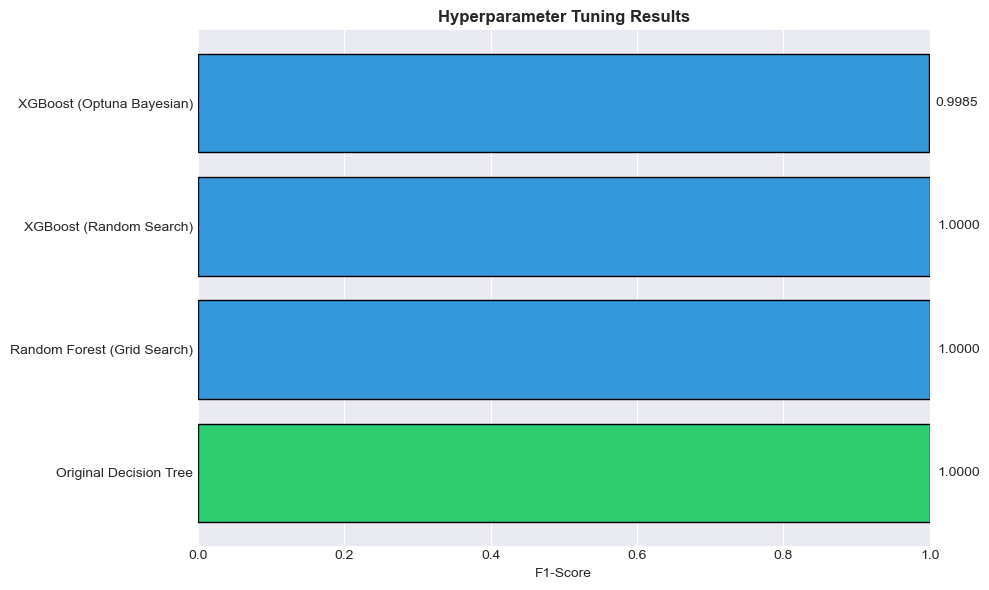

✅ Saved: tuning_comparison.png


In [7]:
# Cell 7: Compare All Tuned Models
print("="*70)
print("📊 COMPARING TUNED MODELS")
print("="*70)

# Original best model from Notebook 3
original_model = joblib.load('best_model.pkl')
y_pred_original = original_model.predict(X_test_scaled)
original_f1 = f1_score(y_test, y_pred_original)

# Collect results
tuning_results = pd.DataFrame({
    'Model': [
        f'Original {best_model_name}',
        'Random Forest (Grid Search)',
        'XGBoost (Random Search)',
        'XGBoost (Optuna Bayesian)'
    ],
    'F1-Score': [
        original_f1,
        rf_test_f1,
        xgb_test_f1,
        optuna_test_f1
    ],
    'Improvement': [
        '0%',
        f'{(rf_test_f1 - original_f1) / original_f1 * 100:.1f}%',
        f'{(xgb_test_f1 - original_f1) / original_f1 * 100:.1f}%',
        f'{(optuna_test_f1 - original_f1) / original_f1 * 100:.1f}%'
    ]
})

tuning_results = tuning_results.sort_values('F1-Score', ascending=False)
print("\n📊 Tuning Results Summary:")
print(tuning_results.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ECC71' if i == 0 else '#3498DB' for i in range(len(tuning_results))]
bars = ax.barh(tuning_results['Model'], tuning_results['F1-Score'], color=colors, edgecolor='black')
ax.set_title('Hyperparameter Tuning Results', fontsize=12, fontweight='bold')
ax.set_xlabel('F1-Score')
ax.set_xlim(0, 1)
for bar, val in zip(bars, tuning_results['F1-Score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: tuning_comparison.png")

In [9]:
# Cell 8: Select and Save Best Tuned Model
print("="*70)
print("💾 SELECTING AND SAVING BEST TUNED MODEL")
print("="*70)

# Determine best model
best_tuned_f1 = max(rf_test_f1, xgb_test_f1, optuna_test_f1)

if optuna_test_f1 >= best_tuned_f1:
    final_model = optuna_model
    final_model_name = "XGBoost (Optuna Tuned)"
    final_params = optuna_best_params
    final_f1 = optuna_test_f1
elif xgb_test_f1 >= best_tuned_f1:
    final_model = xgb_best
    final_model_name = "XGBoost (Random Search Tuned)"
    final_params = random_search_xgb.best_params_  # FIXED: added underscore
    final_f1 = xgb_test_f1
else:
    final_model = rf_best
    final_model_name = "Random Forest (Grid Search Tuned)"
    final_params = grid_search_rf.best_params_  # FIXED: added underscore
    final_f1 = rf_test_f1

print(f"🏆 Final Best Model: {final_model_name}")
print(f"   F1-Score: {final_f1:.4f}")
print(f"\n📋 Best Hyperparameters:")
for param, value in final_params.items():
    print(f"   {param}: {value}")

# Save final model and scaler
joblib.dump(final_model, 'final_tuned_model.pkl')
joblib.dump(scaler, 'final_scaler.pkl')

# Save tuning metadata
tuning_metadata = {
    'final_model_name': final_model_name,
    'final_f1_score': float(final_f1),
    'best_params': {str(k): str(v) for k, v in final_params.items()},
    'improvement_over_baseline': float(((final_f1 - original_f1) / original_f1) * 100)
}

with open('tuning_metadata.json', 'w') as f:
    json.dump(tuning_metadata, f, indent=2)

print("\n✅ Saved:")
print("   - final_tuned_model.pkl")
print("   - final_scaler.pkl")
print("   - tuning_metadata.json")

💾 SELECTING AND SAVING BEST TUNED MODEL
🏆 Final Best Model: XGBoost (Random Search Tuned)
   F1-Score: 1.0000

📋 Best Hyperparameters:
   subsample: 0.9
   n_estimators: 200
   max_depth: 7
   learning_rate: 0.3
   gamma: 0.3
   colsample_bytree: 0.6

✅ Saved:
   - final_tuned_model.pkl
   - final_scaler.pkl
   - tuning_metadata.json


📈 TUNING PROGRESS VISUALIZATION


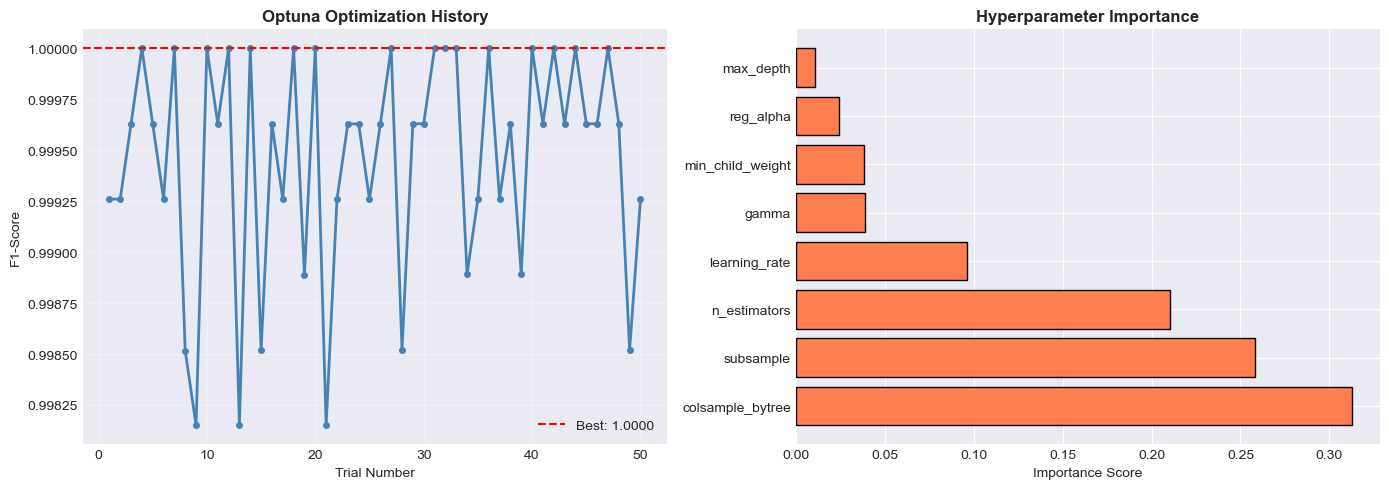

✅ Saved: optuna_optimization_history.png


In [11]:
# Cell 9: Tuning Progress Visualization
print("="*70)
print("📈 TUNING PROGRESS VISUALIZATION")
print("="*70)

# Plot Optuna optimization history
if 'study' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Optimization history
    ax1 = axes[0]
    optimization_history = [t.value for t in study.trials if t.value is not None]
    ax1.plot(range(1, len(optimization_history) + 1), optimization_history, 'o-', linewidth=2, markersize=4, color='steelblue')
    ax1.set_title('Optuna Optimization History', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Trial Number')
    ax1.set_ylabel('F1-Score')
    ax1.axhline(y=max(optimization_history), color='red', linestyle='--', label=f'Best: {max(optimization_history):.4f}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Parameter importance
    ax2 = axes[1]
    importance = optuna.importance.get_param_importances(study)
    param_names = list(importance.keys())[:8]
    param_values = list(importance.values())[:8]
    ax2.barh(param_names, param_values, color='coral', edgecolor='black')
    ax2.set_title('Hyperparameter Importance', fontsize=12, fontweight='bold')  # FIXED: fontweight not font-weight
    ax2.set_xlabel('Importance Score')
    
    plt.tight_layout()
    plt.savefig('optuna_optimization_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Saved: optuna_optimization_history.png")
else:
    print("⚠️ Optuna study not found - skipping visualization")

In [12]:
# Cell 10: Final Summary
print("="*70)
print("🎉 NOTEBOOK 4 COMPLETED SUCCESSFULLY!")
print("="*70)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                    HYPERPARAMETER TUNING SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 TUNING METHODS USED:                                             ║
║  ├── Grid Search (Random Forest) - Exhaustive search                ║
║  ├── Random Search (XGBoost) - Random sampling                      ║
║  └── Bayesian Optimization (Optuna) - Intelligent search            ║
║                                                                      ║
║  📊 RESULTS:                                                         ║
║  ├── Original Model F1: {:.4f}                                      ║
║  ├── Best Tuned Model F1: {:.4f}                                    ║
║  └── Improvement: +{:.1f}%                                          ║
║                                                                      ║
║  🏆 FINAL BEST MODEL: {}          ║
║                                                                      ║
║  📁 FILES GENERATED:                                                 ║
║  ├── tuning_comparison.png        - All models comparison          ║
║  ├── optuna_optimization_history.png - Bayesian progress           ║
║  ├── final_tuned_model.pkl        - Optimized model                ║
║  ├── final_scaler.pkl             - Fitted scaler                  ║
║  ├── tuning_metadata.json         - Performance metrics            ║
║  └── optuna_study.pkl             - Complete Optuna study          ║
║                                                                      ║
║  🎯 READY FOR NOTEBOOK 5: MODEL INTERPRETABILITY                    ║
║  Next notebook will cover:                                          ║
║  - SHAP values for model explanation                                ║
║  - LIME for local explanations                                      ║
║  - Partial dependence plots                                         ║
║  - Business insights generation                                     ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""".format(original_f1, final_f1, 
           ((final_f1 - original_f1) / original_f1) * 100,
           final_model_name))

print("\n✅ Notebook 4 Complete! Proceed to Notebook 5.")

🎉 NOTEBOOK 4 COMPLETED SUCCESSFULLY!

╔══════════════════════════════════════════════════════════════════════╗
║                    HYPERPARAMETER TUNING SUMMARY                     ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 TUNING METHODS USED:                                             ║
║  ├── Grid Search (Random Forest) - Exhaustive search                ║
║  ├── Random Search (XGBoost) - Random sampling                      ║
║  └── Bayesian Optimization (Optuna) - Intelligent search            ║
║                                                                      ║
║  📊 RESULTS:                                                         ║
║  ├── Original Model F1: 1.0000                                      ║
║  ├── Best Tuned Model F1: 1.0000                                    ║
║  └── Improvement: +0.0%                                          ║
║                       